# **PCA – Principal Component Analysis**

PCA is a dimensionality reduction technique that transforms high-dimensional data into a lower-dimensional form while retaining the most important variance (information).



🎯 **Objectives of PCA**:
Reduce computational complexity

Remove multicollinearity

Visualize high-dimensional data

Improve model performance (sometimes)

**Term /Meaning**

Variance - Spread of data

Principal Components- New features formed as combinations of original features

Eigenvectors - Directions of the new feature space

Eigenvalues- Magnitude of variance explained by each eigenvector

**🧮 Steps of PCA:**

Standardize the data.

Compute the covariance matrix.

Compute eigenvalues and eigenvectors of the covariance matrix.

Sort eigenvectors by descending eigenvalues.

Select top K eigenvectors → Principal Components.

Transform original data into the new lower-dimensional space.

**When to Use PCA?**

You have a large number of features.

Features are correlated.

You want to visualize data in 2D or 3D.

You want to reduce overfitting.

We will apply PCA to a 2D dataset and visualize the reduction from 2D to 1D and 2D to 2D (after transformation).

To take a dataset (Iris flower dataset), which has 4 features, and reduce it to 2 features (principal components) using PCA. Then we visualize this 2D data to see how PCA works.

In [ ]:
# Step-by-step PCA Example
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

In [ ]:
# Step 1: Load sample dataset
data = load_iris()


In [ ]:
data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

📘 Understanding the Dataset

We are using the Iris dataset which contains:

150 flower samples.

4 features for each flower:

Sepal Length

Sepal Width

Petal Length

Petal Width

3 flower species: Setosa, Versicolor, Virginica

In [ ]:
X = data.data  # Features: Sepal & Petal lengths/widths # Feature matrix (150 rows × 4 columns)
y = data.target  # Labels: 0, 1, 2 (3 types of Iris flowers)

👉 PCA works best when data is standardized (mean = 0, variance = 1).
This prevents features with larger scales (e.g., Petal Length) from dominating.

In [ ]:
# Step 2: Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

This is the heart of PCA:

We reduce the 4 features down to 2 new features.

These new features (Principal Components) are linear combinations of the original features.

They capture the maximum variance in the data.

In [ ]:

# Step 3: Apply PCA (reduce to 2 components for visualization)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

 Each dot represents a flower. The color (c=y) shows the actual flower species.
This shows how well-separated the flower species are just using 2 components.
You're looking at the Iris dataset, which originally has 4 features:

Sepal Length

Sepal Width

Petal Length

Petal Width

After applying PCA, you reduced those 4 features into just 2 new features:

Principal Component 1 (PC1)

Principal Component 2 (PC2)

Each dot on the graph = one flower (data point)
Each color = one of the 3 Iris species
The colorbar tells you:

0.0 → Purple = Iris Setosa

1.0 → Teal = Iris Versicolor

2.0 → Yellow = Iris Virginica

These are the true labels (from y in the code).

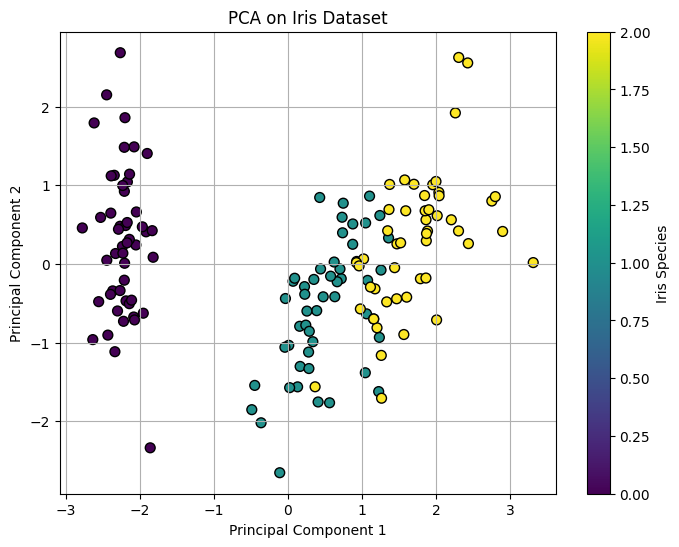

In [ ]:
# Step 4: Plot the result
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA on Iris Dataset')
plt.grid(True)
plt.colorbar(label='Iris Species')
plt.show()

Iris Setosa (Purple dots)

Well-separated from the other two.

Clear clustering = easily distinguishable.

Iris Versicolor (Teal dots) and Iris Virginica (Yellow dots)

These two overlap more.

Harder to separate based on just 2 components (but still some separation).



In [ ]:
# Step 5: Check how much variance is explained
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Captured:", np.sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.72962445 0.22850762]
Total Variance Captured: 0.9581320720000166


Principal Component 1 (PC1) explains about 72.96% of the total variance in the data.

Principal Component 2 (PC2) explains about 22.85% of the total variance.


Total variance captured
This means that together, PC1 and PC2 explain ~95.81% of the original information (variance) from the 4D dataset.

You reduced from 4 features ➝ 2 features, but still retained almost 96% of the original dataset’s meaning.

That’s very efficient! You’ve kept the important structure, patterns, and variation — while simplifying the data.



Imagine your dataset was a 100-page book:

PC1 keeps 73 pages worth of important information.

PC2 keeps 23 pages worth of it.

Together, you now have 96 pages worth of the story — with only 2 pages (features)!